## INTRODUCTION 
    BTG IT Sessions 2026 - Módulo 13: Inteligência Artificial
---


##### CASE: `USA POST RERVICE MNIST`
    Deep learning applied to "MNIST" for the identification of postal code digits used by the US Postal Service in 2011.


#####  ML APPROACH:  
    1 - Simple Neural Network Model
    2 - Deep Learning


##### METRIC : Accuracy
    


-------------------------------------------------------------------------------------

##### SCIKIT-LEARN WEBSITE

[https://scikit-learn.org/stable/](https://scikit-learn.org/stable/)

--------------------------------------------------------------------------------------------------------


## IMPLEMENTATION

 ---

In [1]:
# Installing required libraries

import numpy as np
from pydataset import data
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.utils import to_categorical
from keras.datasets import mnist


I0000 00:00:1787360579.524489  260201 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787360579.527304  260201 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787360579.851188  260201 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787360583.139704  260201 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Usando o método fixo

from libs.IJDEVLibs import IJDEVLibs

libs = IJDEVLibs()


In [3]:
colormap_options = ['Paired', 'grey', 'Reds']

In [4]:
# Load MNIST handwritten digit data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
print(f"x_train.shape :::>>  {x_train.shape}")
print(f"x_test.shape :::>>  {x_test.shape}")

x_train.shape :::>>  (60000, 28, 28)
x_test.shape :::>>  (10000, 28, 28)


In [6]:

print(f"y_train.shape :::>>  {y_train.shape}")
print(f"y_test.shap :::>>  {y_test.shape}")

y_train.shape :::>>  (60000,)
y_test.shap :::>>  (10000,)


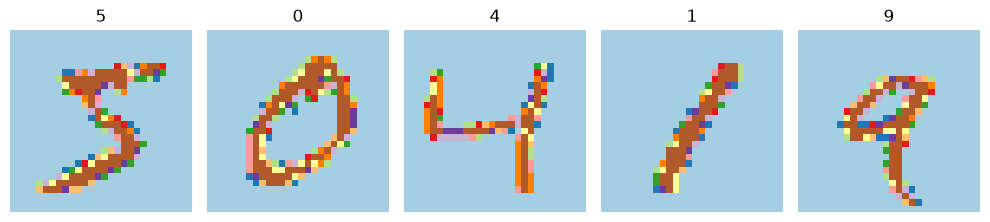

In [7]:
# Chamada da função melhorada

cmap_chosen = libs.get_random_cmap()

libs.smart_make_plot(
    x_data=x_train,        # imagens de treino
    y_data=y_train,        # rótulos correspondentes
    ncols=5,               # número de colunas
    nrows=1,               # número de linhas
    sharex=False,          # não compartilhar eixo x
    sharey=True,           # compartilhar eixo y
    figsize=(10, 4),       # tamanho da figura
    cmap=cmap_chosen       # colormap em escala de cinza
)


In [8]:
to_categorical(3, num_classes=10)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [9]:
# Convert y_train into one-hot format 

temporary_list = []

for i in range(len(y_train)):
    temporary_list.append(to_categorical(y_train[i], num_classes=10))
    
y_train = np.array(temporary_list)


# Convert y_test into one-hot format
temporary_list.clear()

for i in range(len(y_test)):
    temporary_list.append(to_categorical(y_test[i], num_classes=10))
    
y_test = np.array(temporary_list)

In [10]:
print(f"y_train.shape ::>>  {y_train.shape}")
print(f"y_test.shap ::>>  {y_test.shape}")

y_train.shape ::>>  (60000, 10)
y_test.shap ::>>  (10000, 10)


##### SIMPLE NEURAL NETWORK  ARCHITECTURE

In [11]:
# Create a simple Neural Network Model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(5, activation='sigmoid'))    # input layer, 5 neurons
model.add(Dense(10, activation='softmax'))   # output layer, 10 neurons

model.summary()

/home/ijdevpro1/.cache/pypoetry/virtualenvs/btg-it-sessions-2026-module-ai-9LQ4yj_a-py3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1787360587.809897  260201 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,985 (15.57 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile the Neural Network Model

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

In [13]:
# Train the Neural Network Model

snnm_history = model.fit(x_train, y_train, 
                         epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.5128 - loss: 1.6380 - val_acc: 0.6271 - val_loss: 1.2792
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.6634 - loss: 1.1624 - val_acc: 0.7089 - val_loss: 1.0262
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.7020 - loss: 1.0042 - val_acc: 0.6946 - val_loss: 1.0050
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.7202 - loss: 0.9277 - val_acc: 0.7339 - val_loss: 0.9002
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.7220 - loss: 0.9082 - val_acc: 0.7402 - val_loss: 0.8498


In [14]:
predictions = model.predict(x_test)

print(predictions[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[6.6855930e-05 2.0546280e-03 3.5792112e-02 9.8669222e-03 2.5523590e-02
 1.0432987e-03 1.4921949e-03 7.5896180e-01 6.2274728e-03 1.5897109e-01]


In [15]:
predictions = np.argmax(predictions, axis=1)

print(predictions[0])

7


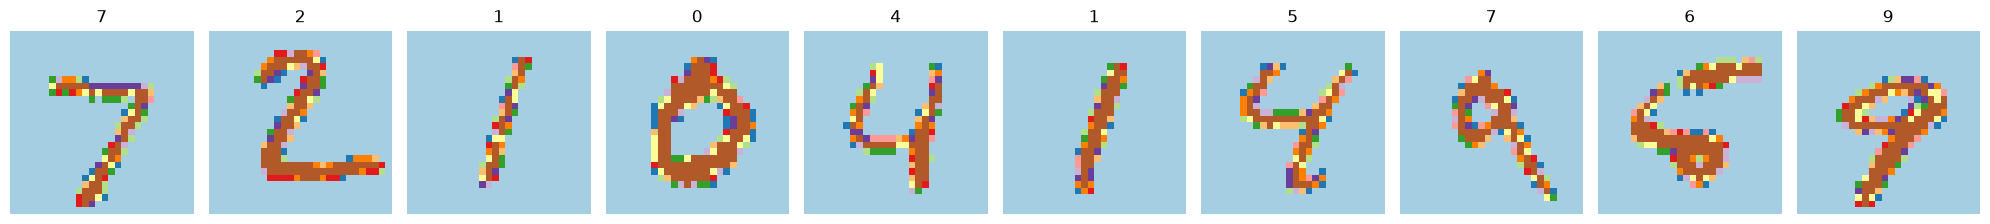

In [16]:
# Chamada da função melhorada

cmap_chosen = libs.get_random_choice(colormap_options)

libs.smart_make_plot(
    x_data=x_test,          # imagens de treino
    y_data=predictions,     # rótulos correspondentes
    ncols=10,               # número de colunas
    nrows=1,                # número de linhas
    sharex=False,           # não compartilhar eixo x
    sharey=True,            # compartilhar eixo y
    figsize=(20, 4),        # tamanho da figura
    cmap=cmap_chosen        # colormap em escala de cinza
)

##### DEEP LEARNING ARCHITECTURE

In [ ]:
# Modelo mais profundo aplicando as 3 camadas de DEEP LEARNING 
#   - Convolução 
#   - Pooling 
#   - Flattening

# ----------------------------------------------------

from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.optimizers import SGD

deep_model = Sequential()
deep_model.add(Conv2D(32, (3, 3), activation='relu',             
    kernel_initializer='he_uniform', input_shape=(28, 28, 1))
)
deep_model.add(MaxPooling2D((2, 2)))
deep_model.add(Flatten())
deep_model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
deep_model.add(Dense(10, activation='softmax'))

# compile model
opt = SGD(learning_rate=0.01, momentum=0.9)
deep_model.compile(optimizer=opt, loss='categorical_crossentropy', 
              metrics=['accuracy'])


deep_model.summary()

/home/ijdevpro1/.cache/pypoetry/virtualenvs/btg-it-sessions-2026-module-ai-9LQ4yj_a-py3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       540,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,230 (2.07 MB)

 Trainable params: 542,230 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
deep_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

In [19]:
# Train the DEEP LEARNING Model
 
# deep_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

history = deep_model.fit(x_train, y_train, 
                         epochs=10, validation_data=(x_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.5920 - loss: 2.5818 - val_acc: 0.6772 - val_loss: 1.0831
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.7162 - loss: 0.8909 - val_acc: 0.7861 - val_loss: 0.8385
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.8397 - loss: 0.5835 - val_acc: 0.8956 - val_loss: 0.4430
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9233 - loss: 0.3523 - val_acc: 0.9470 - val_loss: 0.2566
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9544 - loss: 0.1975 - val_acc: 0.9614 - val_loss: 0.1640
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9679 - loss: 0.1281 - val_acc: 0.9689 - val_loss: 0.1418
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - acc: 0.9741 - loss: 0.1007 - val_acc: 0.9722 - val_loss: 0.1146
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - acc: 0.9801 - loss: 0.0780 - val_acc: 0.9758 - val_loss: 0.1306
Epoch 9/10
1875/1875 ━━━

In [23]:
deep_predictions = deep_model.predict(x_test)

# print(deep_predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [24]:
deep_predictions = np.argmax(deep_predictions, axis=1)

print(deep_predictions[0])

7


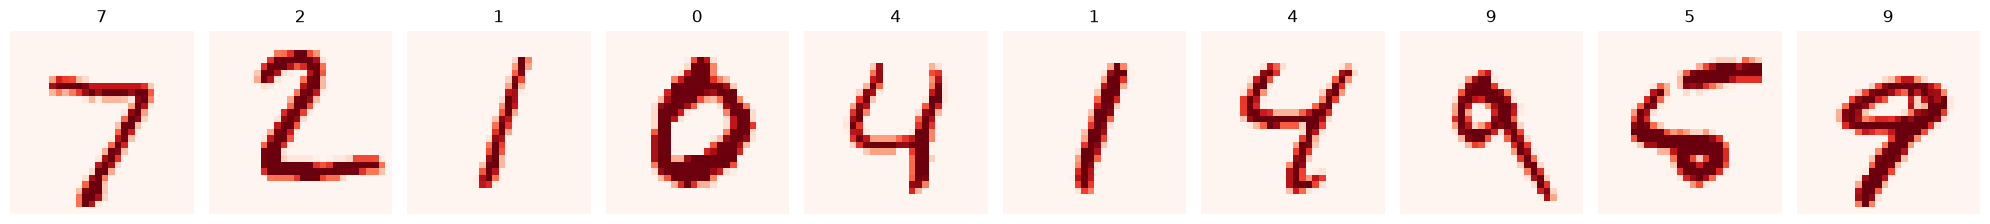

In [25]:
cmap_chosen = libs.get_random_choice(colormap_options)

libs.smart_make_plot(
    x_data=x_test,              # imagens de treino
    y_data=deep_predictions,    # rótulos correspondentes
    ncols=10,               # número de colunas
    nrows=1,                # número de linhas
    sharex=False,           # não compartilhar eixo x
    sharey=True,            # compartilhar eixo y
    figsize=(20, 4),        # tamanho da figura
    cmap=cmap_chosen        # colormap em escala de cinza
)

#### Consolidation of Results

In [30]:
# Consolidação de resultados de todos abordagens testadas acima, mostrando os melhores resultados de cada uma.

# 1 - Rede Neural Simpoles
# 2 - Aprendizado profundo 

# --------------------------------------------------------------------

print("="*80)
print("CONSOLIDATED RESULTS OF ALL MODELS TESTED")
print("="*80)

print("\n")

print("Simple Neural Network Model Strategy\n")

best_epoch, max_val_acc = libs.get_deep_learning_best_acc(
    model_history=snnm_history.history)

print(f" ::>> BEST EPOCH: {best_epoch}")
print(f" ::>> Validation Accuracy: {round((100*max_val_acc), 2)} %")
print("-"*80)

# -----------------------------------------------

print("Deep Learning Strategy\n")

best_epoch, max_val_acc = libs.get_deep_learning_best_acc(
    model_history=history.history)

print(f" ::>> BEST EPOCH: {best_epoch}")
print(f" ::>> Validation Accuracy: {round((100*max_val_acc), 2)} %")
print("-"*80)


CONSOLIDATED RESULTS OF ALL MODELS TESTED


Simple Neural Network Model Strategy

 ::>> BEST EPOCH: 5
 ::>> Validation Accuracy: 74.02 %
--------------------------------------------------------------------------------
Deep Learning Strategy

 ::>> BEST EPOCH: 10
 ::>> Validation Accuracy: 97.67 %
--------------------------------------------------------------------------------


## CONCLUSION

Com base nos treinamentos, testes e análises dos resultados das duas arquiteturas  algorítmos de aprendizado máquina:
- Simple Neural Network 
- Deep Learning Strategy

Chegou-se a uma resposta: 

Fica claramente visível a capacidade SUPERIOR de generalização de uma rede neural embutida na estratégia de aprendizado profundo (deep learning) pelo motivo númerico:

1 - Maior acurácia de validação 

`val_acc (accuracy de validação)` → mostra o desempenho do modelo nos dados de validação, que não foram usados para treinar.

Esse é o valor que realmente indica a capacidade de generalização do modelo para dados novos.
